In [1]:
# Notebook used to track specific rays trajectories from raytrace_3d.py

In [2]:
# %matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import particle_tracker as pt
import ray_transfer_matrix as rtm

from PIL import Image, ImageChops
import yt.units

{'num_photons': '1000000', 'beam_size': '0.012', 'divergence': '0', 'flash_file': '/scratch/ckuranz_root/ckuranz1/timoney/MagShockZ/simuls/3d_shield_v1/MagShockZ_hdf5_plt_cnt_0019', 'scaling_factor': '0.1', 'output_file': 's10', 'num_processors': '36', 'timestamp': '1775798292.4335597'}


yt : [INFO     ] 2026-06-08 16:57:53,427 Parameters: current_time              = 1.050017964457691e-08
yt : [INFO     ] 2026-06-08 16:57:53,429 Parameters: domain_dimensions         = [384 496 384]
yt : [INFO     ] 2026-06-08 16:57:53,431 Parameters: domain_left_edge          = [-0.8   -0.075 -0.8  ]
yt : [INFO     ] 2026-06-08 16:57:53,432 Parameters: domain_right_edge         = [0.8 2.  0.8]
yt : [INFO     ] 2026-06-08 16:57:53,434 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-06-08 16:58:42,725 xlim = -0.800000 0.800000
yt : [INFO     ] 2026-06-08 16:58:42,726 ylim = -0.075000 2.000000
yt : [INFO     ] 2026-06-08 16:58:42,729 xlim = -0.800000 0.800000
yt : [INFO     ] 2026-06-08 16:58:42,730 ylim = -0.075000 2.000000
yt : [INFO     ] 2026-06-08 16:58:42,733 Making a fixed resolution buffer of (('flash', 'edens')) 800 by 800



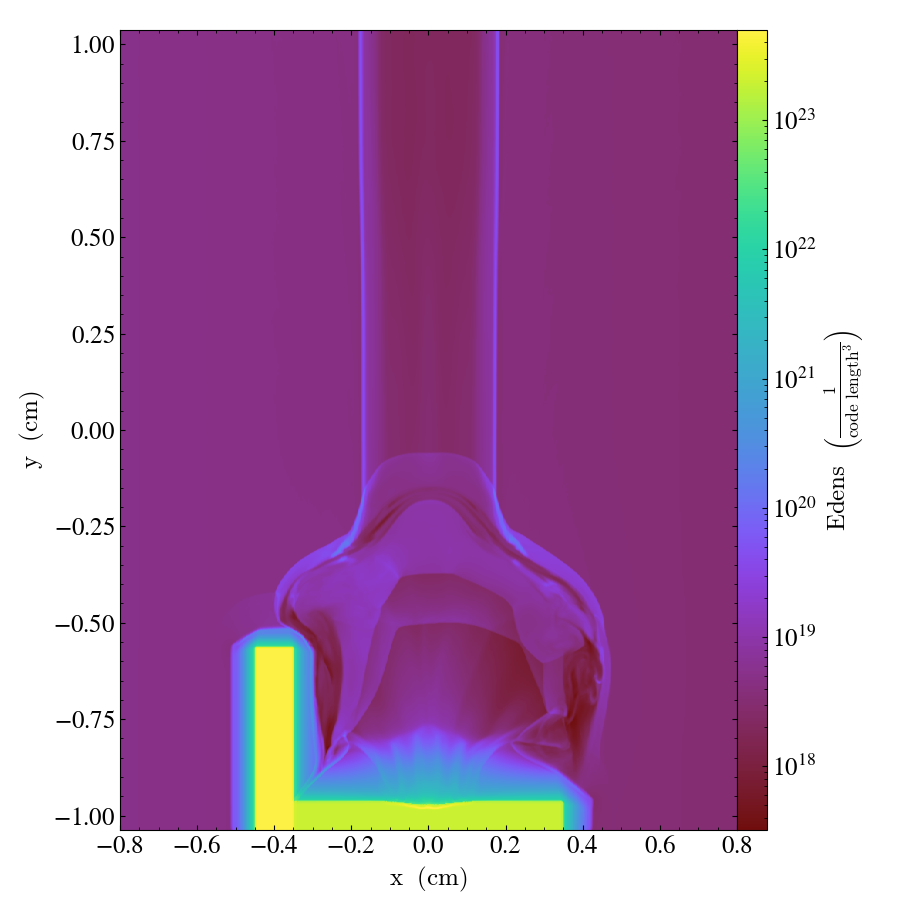

In [3]:
# Get data
ray_trace_dir = '/home/timoney/scratch/timoney/MagShockZ/traces/3d_shield_dens/raytrace_0019_s010'

metadata = {}
raytrace_metadata = ray_trace_dir + '/metadata.txt'
with open(raytrace_metadata, 'r') as f:
    metadata_lines = f.readlines()
    for line in metadata_lines:
        key, value = line.strip().split(': ')
        metadata[key] = value

print(metadata)

ds = yt.load(metadata["flash_file"])

def make_electron_number_density(field, data):
    N_A = yt.units.yt_array.YTQuantity(6.02214076e23, "1/mol")
    proton_mass = yt.units.yt_array.YTQuantity(1.6726219e-24, 'g')
    electron_number_density = N_A*data["flash","dens"]*data["flash","ye"]/proton_mass
    return electron_number_density
ds.add_field(("flash", "edens"), function=make_electron_number_density, units="1/code_length**3",sampling_type="cell") # same here

sl = yt.SlicePlot(ds, 'z', ('flash','edens'))
sl.show()

In [4]:
output_dir = '/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking'
focal_plane = (ds.r[('flash','z')][-1]-ds.r[('flash','z')][0])/2*10 # midplane of simulation (multiply by 10 to convert to mm)
focal_plane = focal_plane.v #take out yt unit

print("focal plane [mm]:", focal_plane)


offset_mm = 0 # offset for focusing
Lens_FL = 400
total_dist = 450+3600 # distance from target to first image plane default = 450 + 3600
if Lens_FL == 400:
    d1= 450
elif Lens_FL == 500:
    d1 = 584.3

d2 =total_dist-d1
Lens_Rad = .5*75 # radius of lens

focal plane [mm]: 7.97916678711772


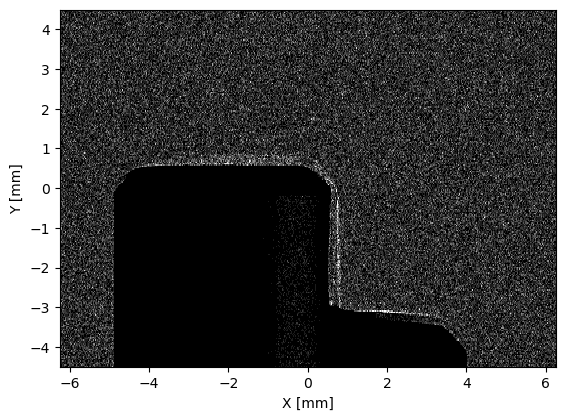

In [12]:
Lens_Rad = 40 # default: 37.5
offset = 0

rf = np.load(f"{ray_trace_dir}/ray_output.npy")
sh = rtm.LIONZ_approx(r0 = rf, Lx = 15, Ly = 17, focal_plane = focal_plane+offset, L=Lens_FL, R=Lens_Rad) # must center grid
sh.solve(d1=d1,d2=d2)

sh.histogram(bin_scale = 5)
fig, axs = plt.subplots()
cm='gray'

vmin=np.percentile(sh.H, 5)
vmax=np.percentile(sh.H, 90) #default is 90

clim=(0,vmax*3) # trial and error
sh.plot(axs, cmap=cm, clim=clim)

plt.ylabel('Y [mm]')
plt.xlabel('X [mm]')
plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
plt.savefig(f'{output_dir}/sh_R={Lens_Rad}mm-off={offset}.png', bbox_inches='tight')
# plt.close()

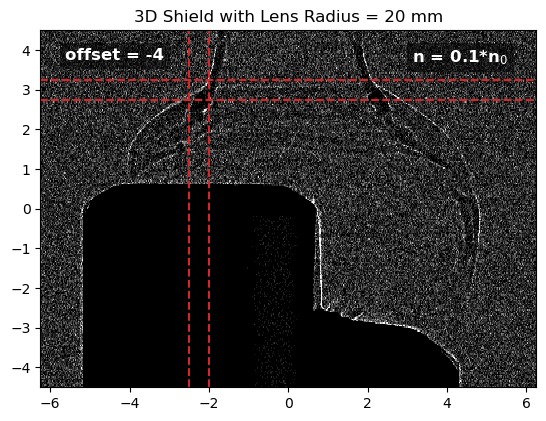

In [171]:
#track rays 
tracker = rtm.Tracked_Shadowgraphy(r0 = rf, Lx = 15, Ly = 17, focal_plane = focal_plane+offset, L=Lens_FL, R=Lens_Rad)
tracker.solve(d1, d2)
tracker.histogram(bin_scale = 5)

#define range 
x_upper = -2
x_lower = -2.5
y_upper = 3.25
y_lower= 2.75

# x_upper = 6
# x_lower = -6
# y_upper = 4
# y_lower= -4

fig, axs = plt.subplots()
tracker.plot(axs, cmap=cm, clim=clim)

plt.axvline(x_upper, linestyle = '--', color = 'tab:red')
plt.axvline(x_lower, linestyle = '--', color = 'tab:red')
plt.axhline(y_upper, linestyle = '--', color = 'tab:red')
plt.axhline(y_lower, linestyle = '--', color = 'tab:red')

scale = 0.1
axs.text(0.75, 0.95, f'n = {scale}*n$_0$', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
axs.text(0.05, 0.95, f'offset = {offset}', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
plt.title(f'3D Shield with Lens Radius = {Lens_Rad} mm')

plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_roi.jpg', bbox_inches='tight')

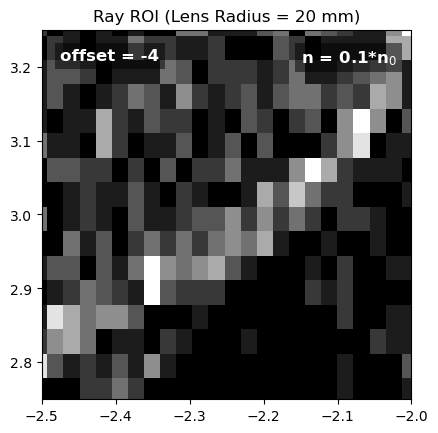

In [172]:
fig, axs = plt.subplots()
tracker.plot(axs, cmap=cm, clim=clim)
plt.ylim(y_lower, y_upper)
plt.xlim(x_lower, x_upper)

axs.text(0.7, 0.95, f'n = {scale}*n$_0$', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
axs.text(0.05, 0.95, f'offset = {offset}', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

plt.title(f'Ray ROI (Lens Radius = {Lens_Rad} mm)')
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_roi_zoom.jpg', bbox_inches='tight')

In [173]:
# find rays in region of interest
# between (-3, 2) and (-2, 3) - defined above
tagged_indices = []
for j in range(len(tracker.rf[0, :])):
    if ((tracker.rf[0, j] > x_lower) & (tracker.rf[0, j] < x_upper) & (tracker.rf[2, j] < y_upper) & (tracker.rf[2, j] > y_lower)):
        tagged_indices.append(j)

print('number of tagged rays:', len(tagged_indices))

number of tagged rays: 604


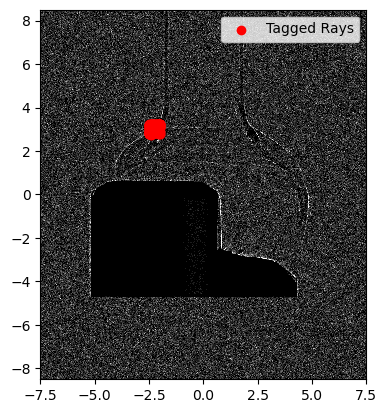

In [174]:
# validate that chosen rays are within the RoI
tracker.histogram(bin_scale=5)

fig, ax = plt.subplots()
cm='gray'
vmin=np.percentile(tracker.H, 5)
vmax=np.percentile(tracker.H, 90) #default is 90
clim=(0,vmax*3) # trial and error
tracker.plot(axs, cmap=cm, clim=clim)

tracker.plot(ax, clim=clim, cmap=cm)

# get final x and y coordinates for tracked rays
final_x = tracker.rf[0, tagged_indices]
final_y = tracker.rf[2, tagged_indices]

ax.scatter(final_x, final_y, color='red', label='Tagged Rays')
ax.legend()
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_tagged.jpg', bbox_inches='tight')

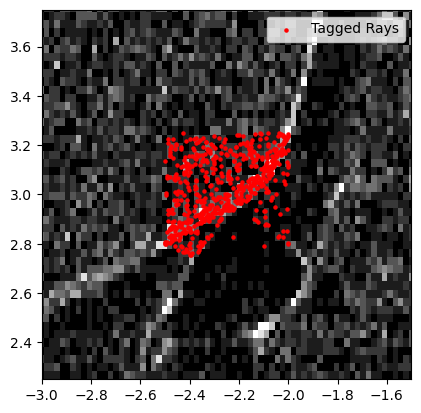

In [175]:
# zoom in on ROI

fig, ax = plt.subplots()
cm='gray'
vmin=np.percentile(tracker.H, 5)
vmax=np.percentile(tracker.H, 90) #default is 90
clim=(0,vmax*3) # trial and error
tracker.plot(axs, cmap=cm, clim=clim)

tracker.plot(ax, clim=clim, cmap=cm)

# get final x and y coordinates for tracked rays
final_x = tracker.rf[0, tagged_indices]
final_y = tracker.rf[2, tagged_indices]

ax.scatter(final_x, final_y, color='red', label='Tagged Rays', s = 5)
ax.legend()
plt.xlim(-3, -1.5)
plt.ylim(2.25,3.75)
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_tagged_zoom.jpg', bbox_inches='tight')

In [176]:
# get the rays that were cut off by an aperture/optical feature, resulting in NaNs
# get_cut_rays() returns the list of ray arrays that have been cut out and the corresponding z planes they were cut
cut_rays = tracker.get_cut_rays()
print(cut_rays)

# fig, ax = plt.subplots(figsize=(10, 5))
# for tag in cut_rays:
    
#     x_positions = [state[0, tag] for state in tracker.history]
#     ax.plot(tracker.z_planes, x_positions, color='blue', alpha=0.4, linewidth=0.8)

# ax.set_title(f"NaN Rays Trajectories")
# plt.ylim(-15,15)
# plt.xlim(0,1000)
# plt.axvline(d1-(focal_plane/2), linestyle = '--', color = 'tab:red', label = 'Lens 1')
# plt.legend()
# plt.show()
# plt.ylim(-5,5)

76113 rays filtered out (NaNs)
[    41     43     67 ... 999963 999970 999986]


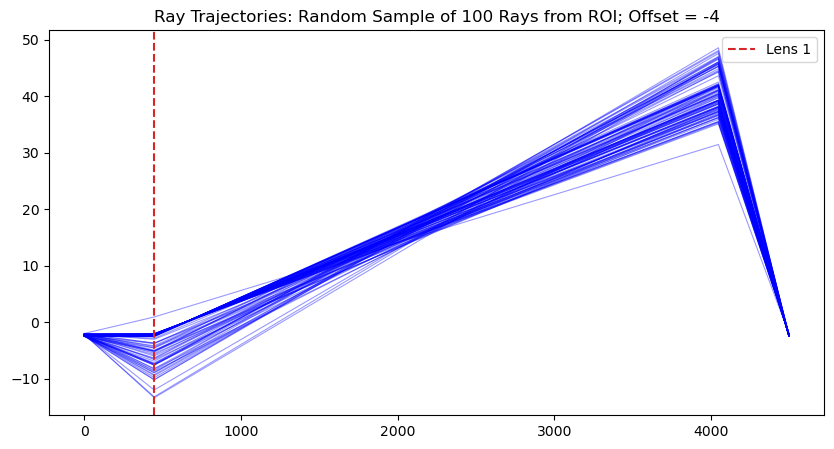

In [177]:
# Randomly select 100 rays from pool of 9000
num_to_plot = 100
sampled_indices = np.random.choice(tagged_indices, size=num_to_plot, replace=False)

fig, ax = plt.subplots(figsize=(10, 5))
for tag in sampled_indices:
    
    x_positions = [state[0, tag] for state in tracker.history]
    ax.plot(tracker.z_planes, x_positions, color='blue', alpha=0.4, linewidth=0.8)

ax.set_title(f"Ray Trajectories: Random Sample of {num_to_plot} Rays from ROI; Offset = {offset}")
# plt.ylim(-15,15)
# plt.xlim(0,1000)
plt.axvline(d1-(focal_plane/2), linestyle = '--', color = 'tab:red', label = 'Lens 1')
plt.legend()
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_paths.jpg', bbox_inches='tight')
# plt.ylim(-5,5)

In [178]:
# now, run raytracing with offset at 0. check trajectories for all the tagged rays

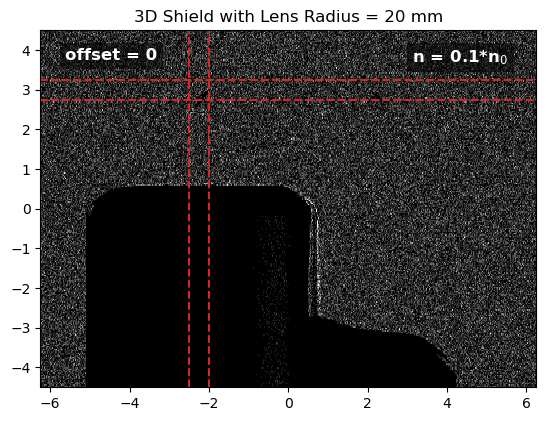

In [179]:
#track rays 
offset = 0
sim_radius = (ds.r[('flash','z')][-1]-ds.r[('flash','z')][0])/2*10 # midplane of simulation (multiply by 10 to convert to mm)
sim_radius=sim_radius.v
tracker_off0 = rtm.Tracked_Shadowgraphy(r0 = rf, Lx = 15, Ly = 17, focal_plane = sim_radius+offset, L=Lens_FL, R=Lens_Rad)
tracker_off0.solve(d1, d2)
tracker_off0.histogram(bin_scale = 5)

fig, axs = plt.subplots()
tracker_off0.plot(axs, cmap=cm, clim=clim)

plt.axvline(x_upper, linestyle = '--', color = 'tab:red')
plt.axvline(x_lower, linestyle = '--', color = 'tab:red')
plt.axhline(y_upper, linestyle = '--', color = 'tab:red')
plt.axhline(y_lower, linestyle = '--', color = 'tab:red')

scale = 0.1
axs.text(0.75, 0.95, f'n = {scale}*n$_0$', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
axs.text(0.05, 0.95, f'offset = {offset}', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
plt.title(f'3D Shield with Lens Radius = {Lens_Rad} mm')

plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_roi.jpg', bbox_inches='tight')

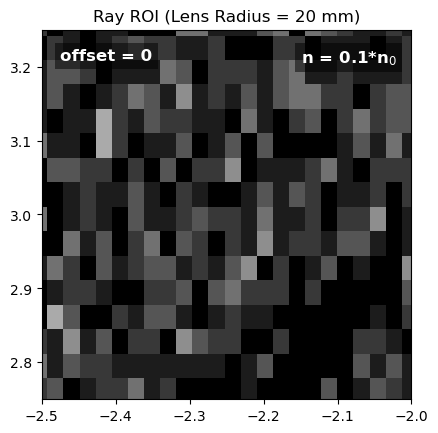

In [180]:
fig, axs = plt.subplots()
tracker_off0.plot(axs, cmap=cm, clim=clim)
plt.ylim(y_lower, y_upper)
plt.xlim(x_lower, x_upper)

axs.text(0.7, 0.95, f'n = {scale}*n$_0$', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
axs.text(0.05, 0.95, f'offset = {offset}', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

plt.title(f'Ray ROI (Lens Radius = {Lens_Rad} mm)')
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_roi_zoom.jpg', bbox_inches='tight')

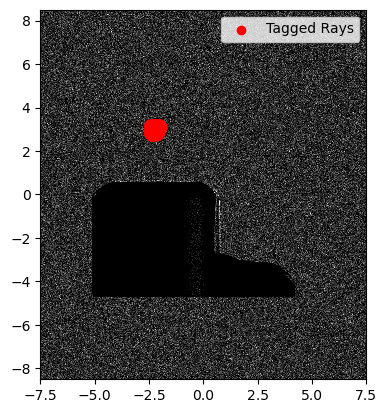

In [181]:
# plot rays that were in original ROI

fig, ax = plt.subplots()
cm='gray'
vmin=np.percentile(tracker.H, 5)
vmax=np.percentile(tracker.H, 90) #default is 90
clim=(0,vmax*3) # trial and error
tracker_off0.plot(axs, cmap=cm, clim=clim)

tracker_off0.plot(ax, clim=clim, cmap=cm)

# get final x and y coordinates for tracked rays
final_x = tracker_off0.rf[0, tagged_indices]
final_y = tracker_off0.rf[2, tagged_indices]

#check that no rays are out of the domain
for i in range(len(final_x)):
    if((final_x[i] > 7.5) or (final_x[i] < -7.5) or (final_y[i] > 8) or (final_y[i] < -8)):
        print('Ray', i, 'out of domain')

ax.scatter(final_x, final_y, color='red', label='Tagged Rays')
ax.legend()
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_tagged.jpg', bbox_inches='tight')

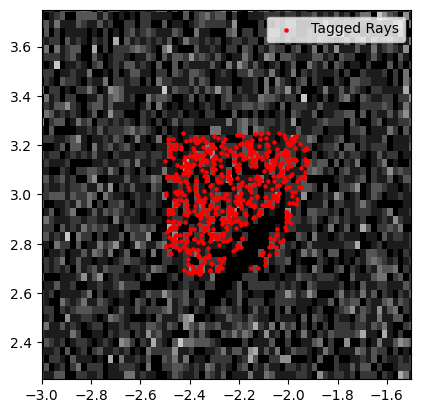

In [182]:
# zoom in on ROI

fig, ax = plt.subplots()
cm='gray'
vmin=np.percentile(tracker.H, 5)
vmax=np.percentile(tracker.H, 90) #default is 90
clim=(0,vmax*3) # trial and error
tracker_off0.plot(axs, cmap=cm, clim=clim)

tracker_off0.plot(ax, clim=clim, cmap=cm)

# get final x and y coordinates for tracked rays
final_x = tracker_off0.rf[0, tagged_indices]
final_y = tracker_off0.rf[2, tagged_indices]

ax.scatter(final_x, final_y, color='red', label='Tagged Rays', s = 5)
ax.legend()
plt.xlim(-3, -1.5)
plt.ylim(2.25,3.75)
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_tagged_zoom.jpg', bbox_inches='tight')

In [183]:
#check if there are any rays that are NaN (cut off by optics)
cut_rays_off0 = tracker_off0.get_cut_rays()

overlap = 0
for i in range(len(tagged_indices)):
    if tagged_indices[i] in cut_rays_off0:
        overlap += 1
print('Number of rays that were cut off when offset = 0 but not when offset = -4 in ROI:', overlap)

76057 rays filtered out (NaNs)
Number of rays that were cut off when offset = 0 but not when offset = -4 in ROI: 0


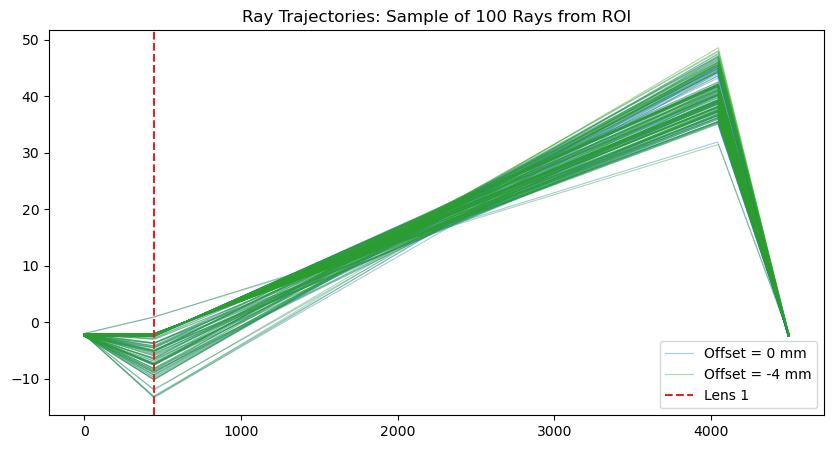

In [195]:
fig, ax = plt.subplots(figsize=(10, 5))
for tag in sampled_indices:
    x_positions = [state[0, tag] for state in tracker_off0.history]
    if tag == 965585:
        ax.plot(tracker_off0.z_planes, x_positions, color='tab:blue', alpha=0.4, linewidth=0.8, label = 'Offset = 0 mm')
    else:
        ax.plot(tracker_off0.z_planes, x_positions, color='tab:blue', alpha=0.4, linewidth=0.8)

for tag in sampled_indices:
    x_positions = [state[0, tag] for state in tracker.history]
    if tag == 965585:
        ax.plot(tracker.z_planes, x_positions, color='tab:green', alpha=0.4, linewidth=0.8, label = 'Offset = -4 mm')
    else:
        ax.plot(tracker.z_planes, x_positions, color='tab:green', alpha=0.4, linewidth=0.8)

ax.set_title(f"Ray Trajectories: Sample of {num_to_plot} Rays from ROI")
# plt.ylim(-15,15)
# plt.xlim(0,1000)
plt.axvline(d1-(focal_plane/2), linestyle = '--', color = 'tab:red', label = 'Lens 1')
plt.legend()
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/paths.jpg', bbox_inches='tight')
# plt.ylim(-5,5)

In [ ]:
# now change the lens radius
